In [1]:
import os
from pathlib import Path

os.environ["NJ_DOMAIN"] = "v4"  # must precede the nj_sfincs import

import sys

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "nj_sfincs").is_dir())
sys.path.insert(0, str(ROOT))

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import Image, display
from matplotlib.colors import BoundaryNorm, ListedColormap
from pyproj import Transformer

from nj_sfincs import domain, plots

DOM = domain.active()
EXP = ROOT / "experiments" / DOM.name
FIGS = ROOT / "reports" / "figures"
FROZEN = DOM.frozen_mesh_dir()

SURFACE, INK, INK_2, GREY, ORANGE = "#fcfcfb", "#0b0b0b", "#52514e", "#c9c8c3", "#eb6834"
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "font.size": 9,
                     "axes.edgecolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2})

g = xr.open_dataset(FROZEN / "sfincs.nc")
FX, FY = g["mesh2d_face_x"].values, g["mesh2d_face_y"].values
MASK, LEV = g["mask"].values, g["level"].values
SIZE = np.round(float(g.attrs["dx"]) / 2.0 ** (LEV - 1))  # dx is 200.00000000000003
with xr.open_dataset(FROZEN / "sfincs_subgrid.nc") as s:
    ZMIN = s["z_zmin"].values
ACT = MASK > 0

TO_UTM = Transformer.from_crs(4326, DOM.epsg, always_xy=True)
RING4 = gpd.read_file(DOM.region).to_crs(DOM.epsg)
RING3 = gpd.read_file(domain.DOMAINS["v3"].region).to_crs(DOM.epsg)
NJ = plots.state_outline(DOM.epsg)
_line = domain.read_waterlevel_line(DOM.waterlevel_line)
LX, LY = TO_UTM.transform([p[1] for p in _line], [p[2] for p in _line])
WIN = (434_000, 628_000, 4_283_000, 4_540_000)


def binned(x, y, v, res, win=WIN, how="max"):
    x0, x1, y0, y1 = win
    nx, ny = int((x1 - x0) / res), int((y1 - y0) / res)
    c, r = ((x - x0) / res).astype(int), ((y1 - y) / res).astype(int)
    ok = (c >= 0) & (c < nx) & (r >= 0) & (r < ny) & np.isfinite(v)
    out = np.full((ny, nx), np.nan)
    flat = r[ok] * nx + c[ok]
    vals = pd.Series(v[ok]).groupby(flat)
    agg = vals.max() if how == "max" else vals.min()
    out.flat[agg.index.values] = agg.values
    return out, (x0, x1, y0, y1)


def frame(ax, win=WIN, ring=True):
    NJ.plot(ax=ax, color=INK_2, lw=0.5, alpha=0.45)
    if ring:
        RING4.boundary.plot(ax=ax, color=INK_2, lw=0.6)
    ax.plot(LX, LY, color=INK, lw=1.0)
    ax.set_xlim(win[0], win[1]); ax.set_ylim(win[2], win[3])
    ax.set_aspect(1); ax.set_xticks([]); ax.set_yticks([])


def peak(run):
    with xr.open_dataset(EXP / run / "sfincs_map.nc") as m:
        zs = m["zsmax"].max("timemax").values
    wet = ACT & np.isfinite(zs) & (zs - ZMIN > 0.10) & (ZMIN < 6.0)
    return np.where(wet, zs, np.nan)


print(DOM.name, "| faces", f"{len(FX):,}", "| active", f"{ACT.sum():,}")

v4 | faces 4,881,654 | active 3,974,165


## v4 region vs v3

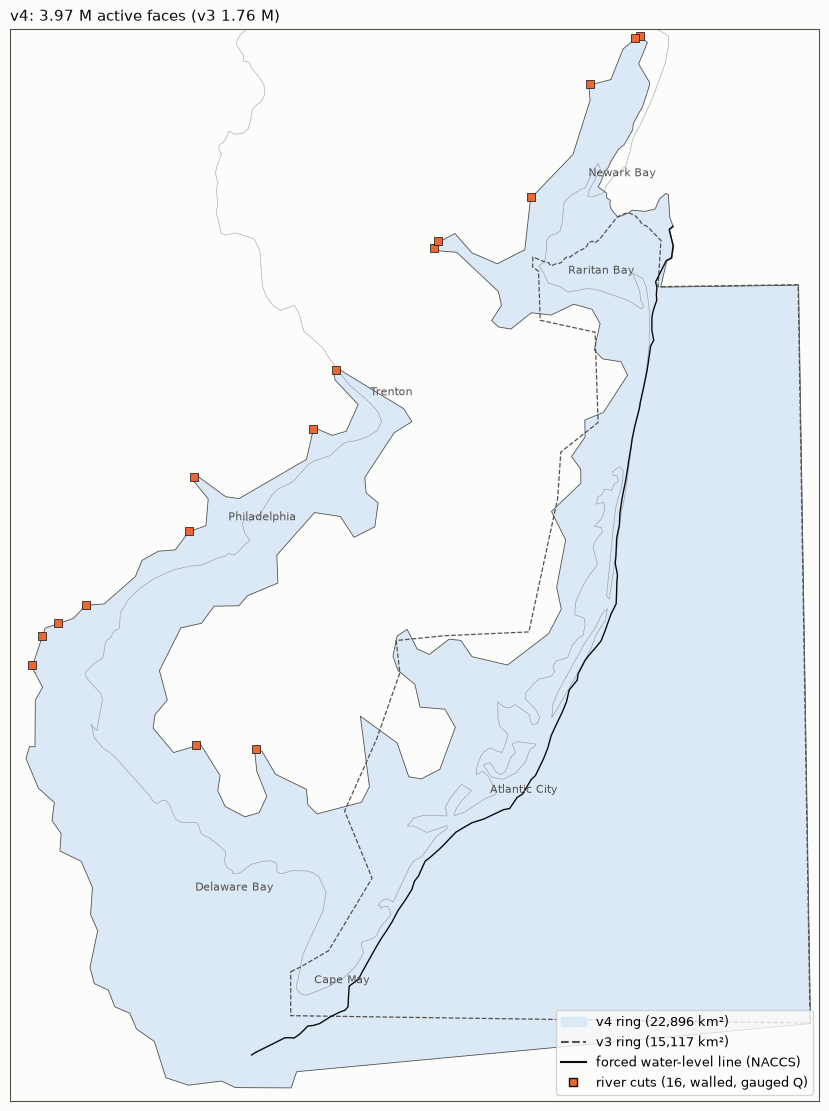

In [2]:
fig, ax = plt.subplots(figsize=(9, 11), constrained_layout=True)
RING4.plot(ax=ax, color="#dbe8f6", edgecolor=INK_2, lw=0.6)
RING3.boundary.plot(ax=ax, color=INK_2, lw=0.9, ls="--")
frame(ax, ring=False)
cuts = [(n, (b[0] + b[2]) / 2, (b[1] + b[3]) / 2) for n, b, _ in domain._V4_RIVER_CUTS]
ax.scatter([c[1] for c in cuts], [c[2] for c in cuts], s=28, marker="s", color=ORANGE,
           edgecolor=INK, lw=0.5, zorder=5)
for lab, lon, lat in [("Delaware Bay", -75.25, 39.15), ("Trenton", -74.76, 40.22),
                      ("Philadelphia", -75.16, 39.95), ("Newark Bay", -74.14, 40.69),
                      ("Raritan Bay", -74.20, 40.48), ("Atlantic City", -74.43, 39.36),
                      ("Cape May", -74.92, 38.95)]:
    x, y = TO_UTM.transform(lon, lat)
    ax.text(x, y, lab, fontsize=8, color=INK_2)
ax.legend(handles=[
    plt.matplotlib.patches.Patch(color="#dbe8f6", label=f"v4 ring ({RING4.to_crs(6933).area.sum() / 1e6:,.0f} km²)"),
    plt.Line2D([], [], color=INK_2, ls="--", label=f"v3 ring ({RING3.to_crs(6933).area.sum() / 1e6:,.0f} km²)"),
    plt.Line2D([], [], color=INK, label="forced water-level line (NACCS)"),
    plt.Line2D([], [], ls="", marker="s", mfc=ORANGE, mec=INK, label=f"river cuts ({len(cuts)}, walled, gauged Q)"),
], loc="lower right", facecolor=SURFACE)
ax.set_title(f"v4: {ACT.sum() / 1e6:.2f} M active faces (v3 1.76 M)", loc="left", color=INK);

## Mesh resolution — face size of every active cell

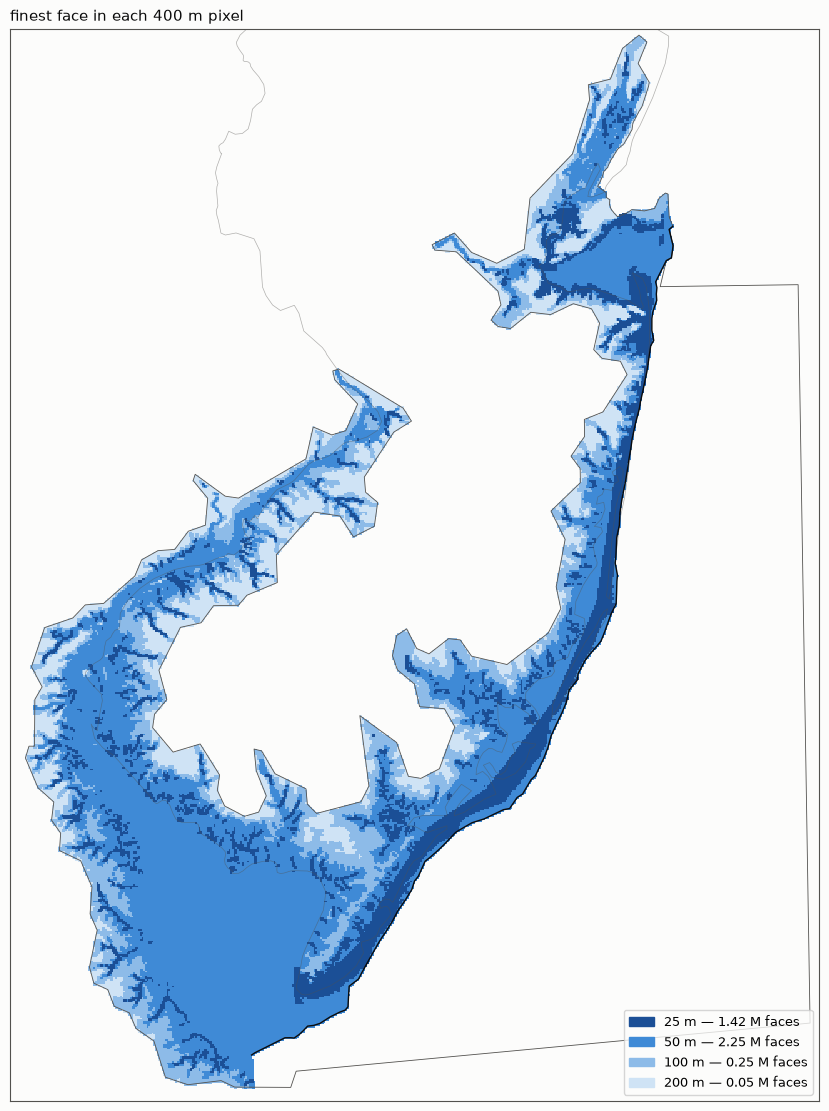

In [3]:
img, ext = binned(FX[ACT], FY[ACT], SIZE[ACT], 400.0, how="min")
cmap = ListedColormap(["#1b4f96", "#3f8ad6", "#8dbbe8", "#cfe3f5"])
norm = BoundaryNorm([0, 37.5, 75, 150, 300], cmap.N)
fig, ax = plt.subplots(figsize=(9, 11), constrained_layout=True)
ax.imshow(img, extent=ext, cmap=cmap, norm=norm, interpolation="nearest")
frame(ax)
counts = {s: int((ACT & (SIZE == s)).sum()) for s in (25, 50, 100, 200)}
ax.legend(handles=[plt.matplotlib.patches.Patch(color=cmap(norm(s)), label=f"{s} m — {n / 1e6:.2f} M faces")
                   for s, n in counts.items()], loc="lower right", facecolor=SURFACE)
ax.set_title("finest face in each 400 m pixel", loc="left", color=INK);

## Where waves will be computed (SnapWave domain, not yet run)

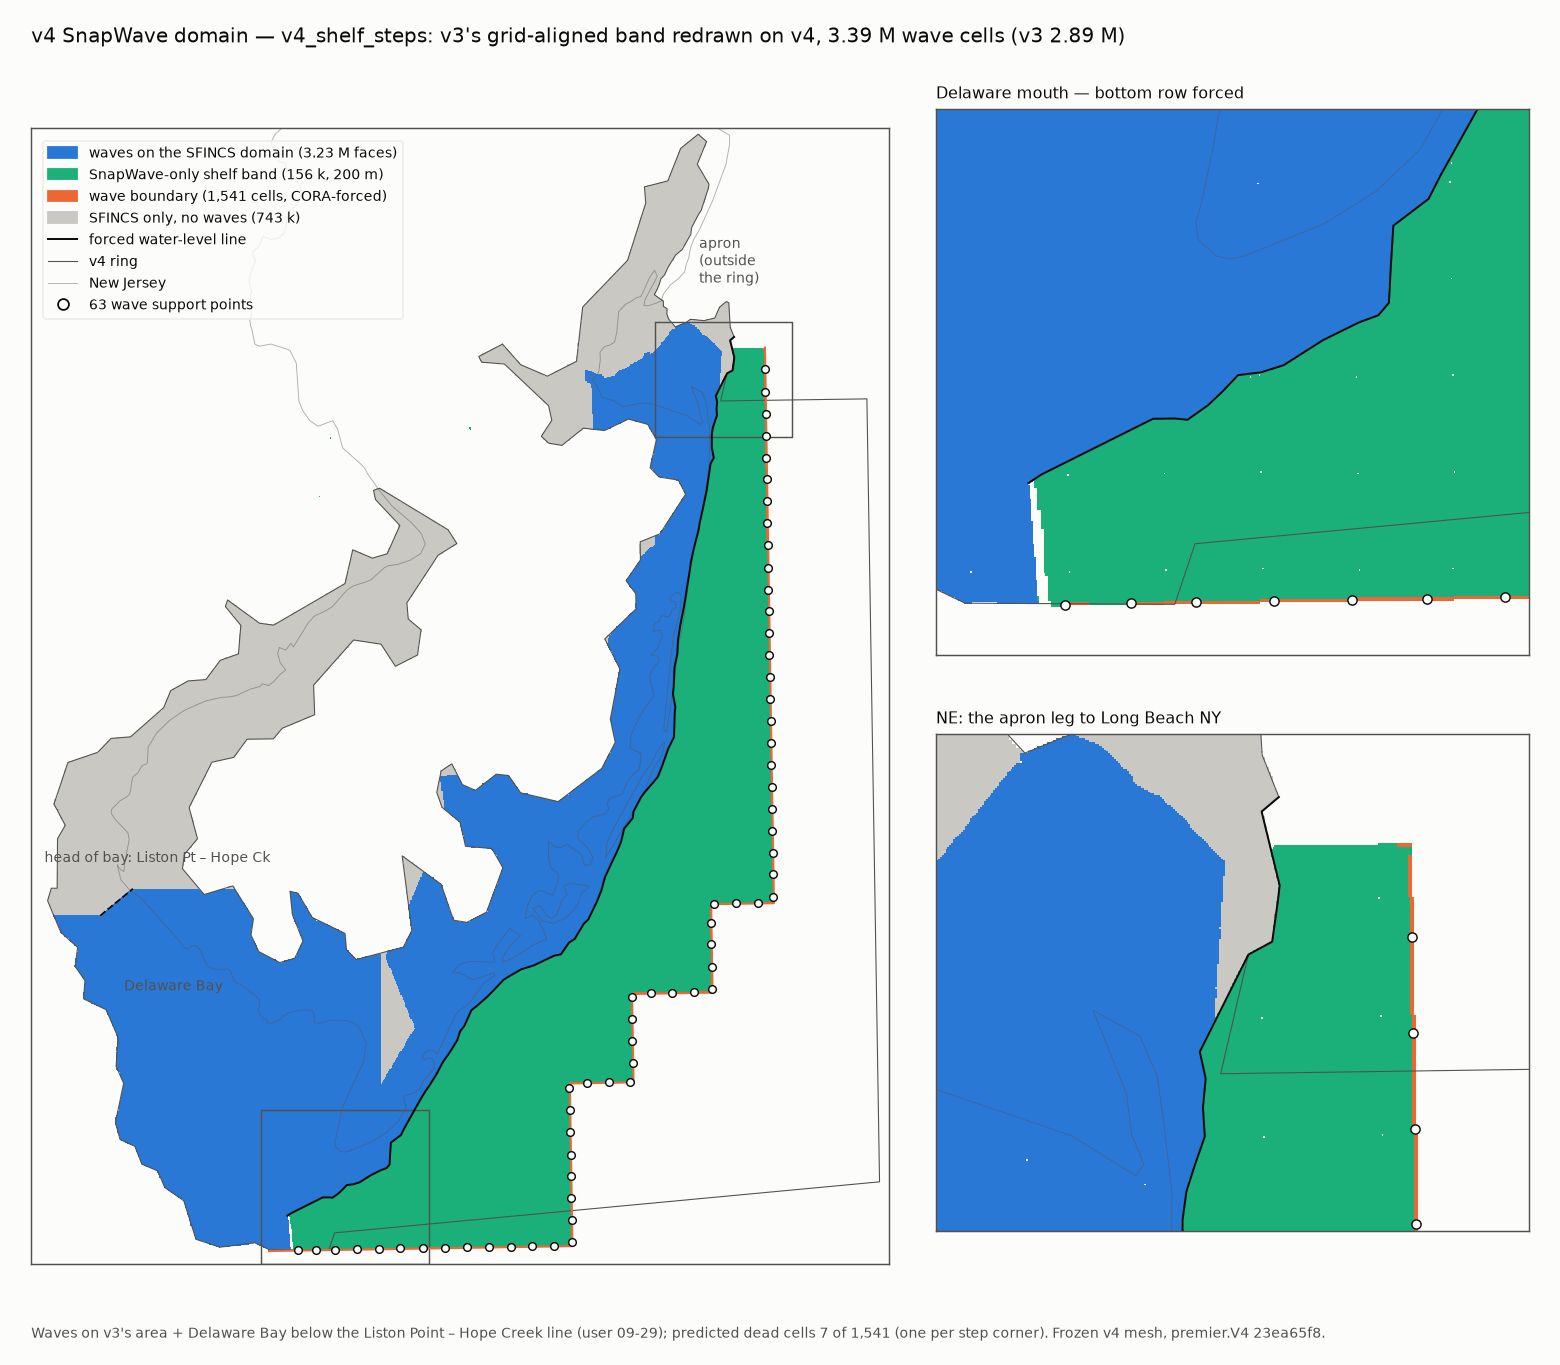

In [4]:
display(Image(FIGS / "v4_snapwave_domain.png", width=1100))

## FEMA MOTF extent as scored — NJ land only

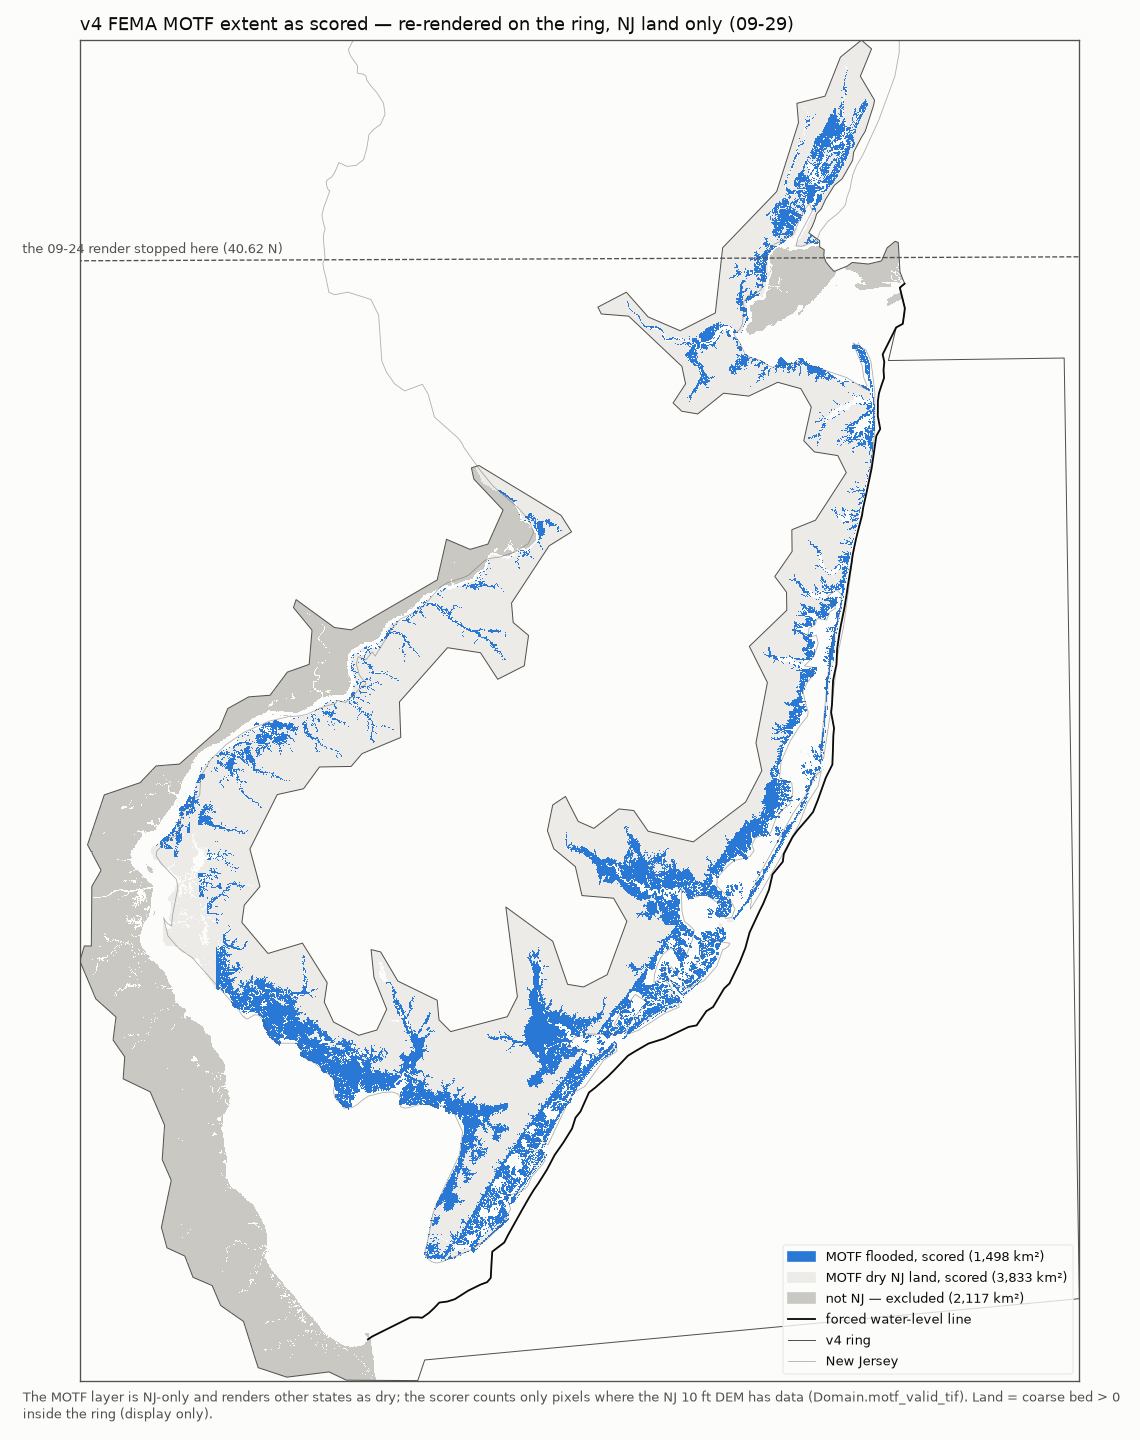

In [5]:
display(Image(FIGS / "v4_motf_scored.png", width=750))

## Peak water-surface elevation — Sandy, waves off, rain off (+0 m run)

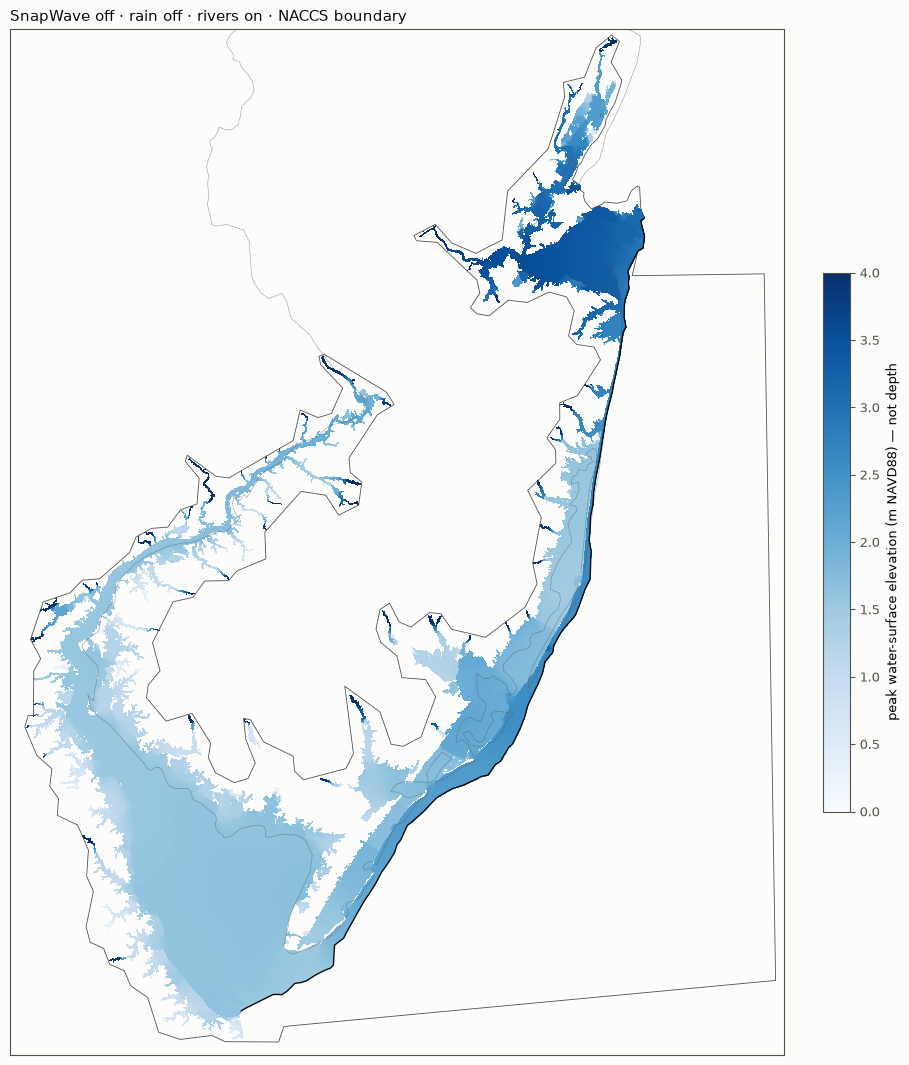

In [6]:
zs0 = peak("naccs-nowaves+rain-off+slr-0m")
img, ext = binned(FX, FY, zs0, 250.0)
fig, ax = plt.subplots(figsize=(9, 11), constrained_layout=True)
im = ax.imshow(img, extent=ext, cmap="Blues", vmin=0, vmax=4, interpolation="nearest")
frame(ax)
fig.colorbar(im, ax=ax, shrink=0.5, label="peak water-surface elevation (m NAVD88) — not depth")
ax.set_title("SnapWave off · rain off · rivers on · NACCS boundary", loc="left", color=INK);

## Sea-level ladder — peak water-surface elevation at +0 / +2 / +3 m (rain off)

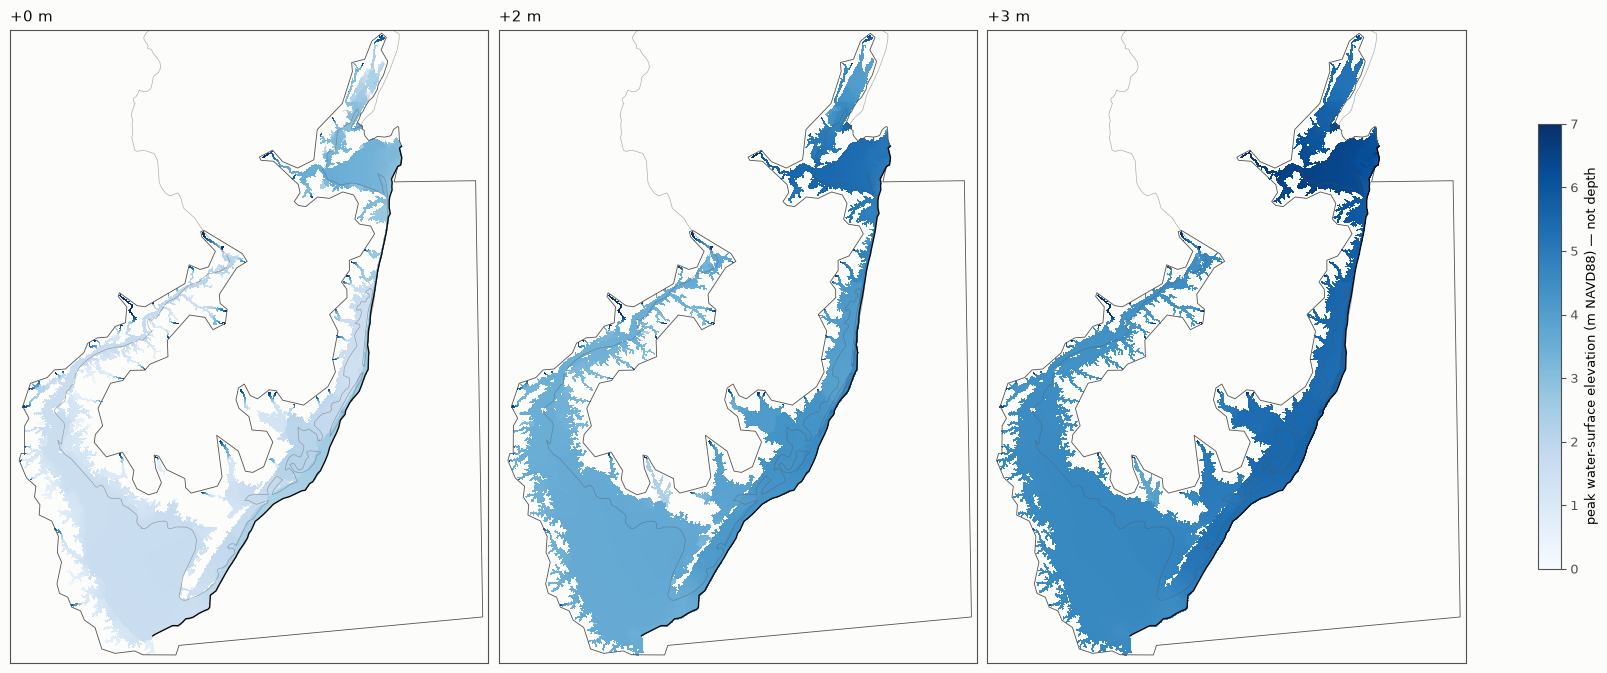

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 7.5), constrained_layout=True)
for ax, dz in zip(axes, (0, 2, 3)):
    img, ext = binned(FX, FY, peak(f"naccs-nowaves+rain-off+slr-{dz}m"), 400.0)
    im = ax.imshow(img, extent=ext, cmap="Blues", vmin=0, vmax=7, interpolation="nearest")
    frame(ax)
    ax.set_title(f"+{dz} m", loc="left", color=INK)
fig.colorbar(im, ax=axes, shrink=0.6, label="peak water-surface elevation (m NAVD88) — not depth");

## Gauges — observed vs model, waves off · ⚠️ flat model lines = the gauge point sits on a dry bank cell (Cape May, Barnegat Light, Absecon Ck, Inside Thorofare, Cape May Harbor, Sluice Ck); smooth rise = creek channel not in the bed (Murderkill at Frederica, Christina at Newport) · breaks in black = USGS gaps (10-29 EDT missing at 12 USGS gauges in the published record)

No region component found in components.


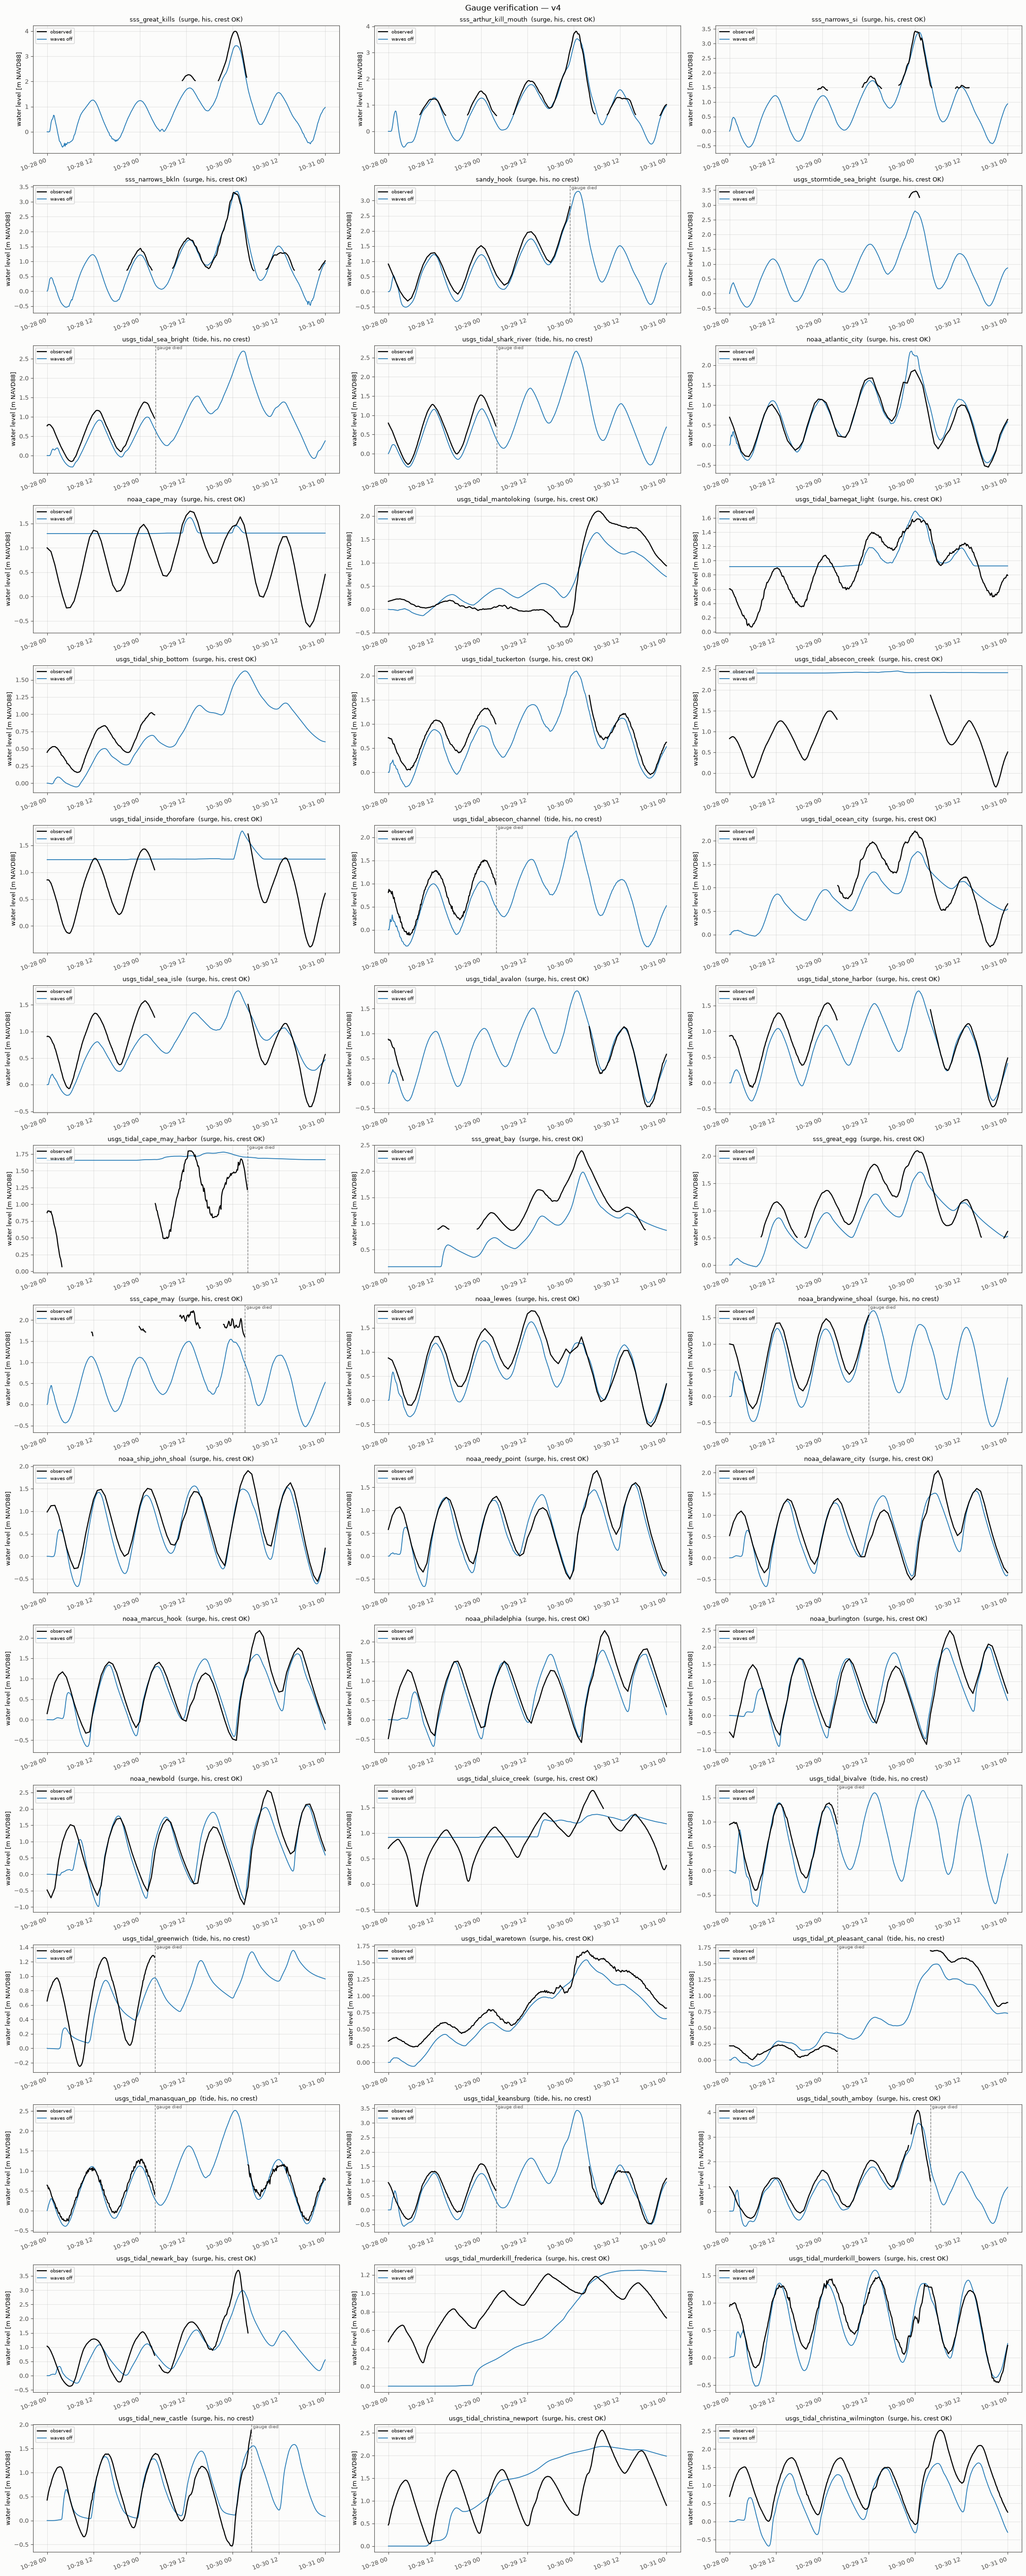

In [8]:
plots.plot_gauge_verification({"waves off": "naccs-nowaves"}, ncol=3);

## Scores — waves off (preliminary)

In [9]:
m = pd.read_csv(EXP / "metrics.csv", index_col=0) if (EXP / "metrics.csv").exists() else pd.DataFrame()
if "naccs-nowaves" not in m.index:
    print("scoring still running — re-run this cell when job 62036907 finishes")
else:
    r = m.loc["naccs-nowaves"]
    head = ["hwm_estimator", "hwm_radius_m", "hwm_n_scored", "hwm_bias_scored_m",
            "hwm_rmse_scored_m", "hwm_within0.5_scored", "motf_csi", "motf_pod", "motf_far",
            "motf_km2_excluded_invalid"]
    display(r.reindex(head).to_frame("naccs-nowaves"))
    basins = domain.hwm_basin_names()
    tab = pd.DataFrame({b: {"n": r.get(f"hwm_n_scored_{b}"), "bias (m)": r.get(f"hwm_bias_scored_{b}_m"),
                            "RMSE (m)": r.get(f"hwm_rmse_scored_{b}_m")} for b in basins}).T
    display(tab[tab["n"].fillna(0) > 0].astype(float).round(3))

scoring still running — re-run this cell when job 62036907 finishes
